# C2 — Backward-module ablation (single run)

Fills the **KAN block** of Table C2 in `Results.tex` (`tab: ablation-backward`).
Single seed, one run per variant — the point is to *see the numbers and the
convergence behaviour first*, before committing to a 5-seed sweep.

The forward module is held fixed at KAN `[18,6,6,6]`; only the backward module
changes:

| Row | Forward | Backward | Loss |
|---|---|---|---|
| `kan_star_ce` | KAN `[18,6,6,6]` | none | cross-entropy |
| `logic_kan_star` | KAN `[18,6,6,6]` | logic tensor, six per-class rules | `1 - sat` |
| `h_logic_kan_star` | KAN `[18,6,6,6]` | logic + hierarchy | `1 - sat` |

Plus one row that belongs to **Table C1**, not C2:

| Row | Forward | Backward | Loss |
|---|---|---|---|
| `logic_mlp_hier` | MLP `[18,6,6,6]` | logic + hierarchy | `1 - sat` |

`logic_mlp_hier` is the missing MLP row of the forward-axis table: identical
backward module to `h_logic_kan_star`, MLP forward path instead of the KAN,
depth-matched but not capacity-matched (198 vs 2520 trainable parameters).
It is **not** the paper's Section IV-A Logic-MLP, which is `MLP(18,10,6)` with
the *flat* rule set.

### Why `[18,6,6,6]` and not `[18,10,6]`

`[18,6,6,6]` is the KAN backbone inside P5's `AttentionKANModel`. Choosing it
here makes the last row **exactly `H-Logic-KAN*`**, and therefore:

| Model | Forward | Backward |
|---|---|---|
| `h_logic_kan_star` (this notebook) | KAN `[18,6,6,6]` | logic + hierarchy |
| Attn-LogiK-Net (full) (from P5) | attention → KAN `[18,6,6,6]` | logic + hierarchy |

These two differ by **exactly the attention encoder**. So the two blocks of
Table C2 can be read *across* as well as *within*, and the same pair doubles as
a clean forward-axis contrast for Table C1 — with no new model needed.

The **attention block** of Table C2 is already done: P5's
`attn_kan_noLTN_2_6.pt` / `attn_kan_2_6.pt`, trained on this same
`logiKNet_train_10000.csv` split. Nothing from P5 is retrained here.

### `flat` vs `hier` — rule sets, NOT architecture

`KAN_WIDTH` is the *forward* module's shape. `flat` / `hier` describe the
*backward* module's rule set and say nothing about network depth:

* **`flat`** — six per-class rules, `∀x labelled c : P(x, c)`. This is ordinary
  supervision restated in fuzzy logic. It encodes **no** relationship between
  classes: class 0 and class 5 are as unrelated as class 0 and class 1.
* **`hier`** — those six, plus one more:
  `∀x ∈ MQTT (labels 0..4) : ¬P(x, Benign)`. This is the only place the class
  **tree** enters training. It groups labels 0–4 into a single LTN variable and
  applies one joint constraint, putting gradient pressure specifically on the
  security-critical error — calling an attack benign — rather than spreading it
  evenly over all confusions. It is not derivable from the six per-class rules.

In `compute_sat_levels` the difference is literally the `if hierarchical:`
branch that appends one `Forall` term.

### Other assumptions — change them in the Config cell

1. **Train split `logiKNet_train_10000.csv`** — the agreed §C protocol, and the
   split P5 already used, so both C2 blocks are protocol-matched.
2. **Seed 42**, matching `AttentionEncoder.ipynb`.
3. **Epoch budget is measured, not assumed.** Each variant trains for its full
   budget while its test accuracy is traced every `ACC_EVERY` epochs, and
   reports `plateau_epoch` — the first epoch within `0.002` of its own best
   accuracy. That is the number to copy into `CONVERGE` in
   `run_multiseed_c2.py`; the argmax (`best_epoch`) is noise-sensitive.
   Loss-based early stopping exists but is **off** (`EARLY_STOP = False`) so the
   whole curve is visible.

> Requires `ltn`: `pip install LTNtorch` (provides the `ltn` module).

In [1]:
# --- imports & paths ---
import os, sys, json, time
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import StandardScaler

# utils.py / MultiKANModel live in P1_structurelevel; eval_metrics.py in P5_attention.
sys.path.append(os.path.abspath('.'))
sys.path.append(os.path.abspath('../P1_structurelevel'))
sys.path.append(os.path.abspath('../P5_attention'))

from utils import LogitsToPredicate, MultiKANModel, MLP, DataLoader
from kan import KAN
import ltn
import ltn.fuzzy_ops
from eval_metrics import evaluate_run, CHILD_TO_PARENT_6, LABEL_L2_NAMES

# CUDA or CPU, never MPS: LTN Constants stay on CPU while the model moves to the
# GPU, which raises "expected all tensors on the same device".
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cpu


In [2]:
# --- Config (edit here) ---
TRAIN_PATH = '../P1_structurelevel/efficiency/input_files/logiKNet_train_10000.csv'
TEST_PATH  = '../P1_structurelevel/efficiency/input_files/logiKNet_test_3994.csv'

X_columns = [
    'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate',
    'IPv', 'LLC',
    'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number',
    'Magnitue', 'Radius', 'Covariance',
]

label_L2_names = {
    0: "MQTT-DDoS-Connect_Flood", 1: "MQTT-DDoS-Publish_Flood",
    2: "MQTT-DoS-Connect_Flood",  3: "MQTT-DoS-Publish_Flood",
    4: "MQTT-Malformed_Data",     5: "Benign",
}
BENIGN_L2 = 5                      # 0..4 -> MQTT (L1=0), 5 -> Benign (L1=1)

IN_FEATURES = len(X_columns)       # 18
N_CLASSES   = len(label_L2_names)  # 6
# Forward module, HELD FIXED across all three rows.
# [18,6,6,6] (two hidden layers of 6) is deliberately chosen to match the KAN
# backbone inside P5's AttentionKANModel. Consequence: the 'Logic + hierarchy'
# row below IS H-Logic-KAN*, and it differs from Attn-LogiK-Net (full) by
# EXACTLY the attention encoder -- so the two blocks of Table C2 become
# readable across, not merely within.
KAN_WIDTH   = [IN_FEATURES, 6, 6, N_CLASSES]
# C1 forward-axis row: MLP forward path, depth-matched to KAN_WIDTH.
# Smaller in parameters than the KAN (198 vs 2520) -- matched on depth, not
# capacity. This is a deliberate choice; see the C1 caption in Results.tex.
MLP_WIDTH   = [IN_FEATURES, 6, 6, N_CLASSES]

SEED   = 42
LR     = 1e-3
# --- per-variant training budget -------------------------------------------
# This section is a PERFORMANCE comparison, not an epoch-matched fairness test:
# each variant is allowed to train to its own best. Set a generous budget here,
# read the accuracy trace, then come back and set the budget you actually want.
# Any cell can also override with  run_variant(key, epochs=N).
EPOCHS_BY_VARIANT = {
    'kan_star_ce':      600,
    'logic_kan_star':   800,
    'h_logic_kan_star': 800,
}
EPOCHS = 800            # fallback / safety cap

ACC_EVERY  = 100         # evaluate + print TEST accuracy every N epochs
EVAL_EVERY = 100         # print loss/satisfaction every N epochs

# --- optional early stopping on ACCURACY (off by default) -------------------
# Off so you can see the whole curve and choose the stopping point yourself.
# When on: stop if the best test accuracy has not improved by more than
# ACC_MIN_DELTA for ACC_PATIENCE consecutive accuracy checks.
EARLY_STOP    = False
ACC_PATIENCE  = 5        # in units of ACC_EVERY epochs
ACC_MIN_DELTA = 1e-4

# NOTE ON RIGOR: the trace below is TEST accuracy, matching the original
# notebooks. Choosing a stopping epoch from it is technically test-set peeking.
# For the paper, either (a) state that the budget was fixed from a pilot run and
# then held constant across all seeds -- which is what we do, so the seeds are
# still clean -- or (b) carve a validation split off the training data.

# FAST_DEV: train on the small 3994-row file just to confirm everything runs.
# Set False for the real run.
FAST_DEV = False

SAVE_DIR = './saved'
os.makedirs(SAVE_DIR, exist_ok=True)
print('IN_FEATURES =', IN_FEATURES, '| N_CLASSES =', N_CLASSES,
      '| KAN_WIDTH =', KAN_WIDTH)

IN_FEATURES = 18 | N_CLASSES = 6 | KAN_WIDTH = [18, 6, 6, 6]


In [3]:
# --- 1. Read input data ---
if FAST_DEV:
    train_df = pd.read_csv(TEST_PATH)
    test_df  = pd.read_csv(TEST_PATH)
    print('FAST_DEV: training on the 3994-row file (sanity check only)')
else:
    train_df = pd.read_csv(TRAIN_PATH)
    test_df  = pd.read_csv(TEST_PATH)

# The CSVs are Git LFS-tracked; without `git lfs pull` they are ~130-byte
# pointer stubs that pandas parses into a 1-column frame.
missing = [c for c in X_columns + ['label_L2'] if c not in train_df.columns]
assert not missing, (f'missing columns in train file: {missing}\n'
                     'If ALL are missing, the CSV is a Git LFS pointer -- run '
                     '`git lfs install && git lfs pull` from the repo root.')

scaler = StandardScaler()
train_X_scaled = scaler.fit_transform(train_df[X_columns])
test_X_scaled  = scaler.transform(test_df[X_columns])
print('train shape:', train_X_scaled.shape, '| test shape:', test_X_scaled.shape)
print('NaN/Inf in train:', np.isnan(train_X_scaled).any(), np.isinf(train_X_scaled).any())

train_y = train_df['label_L2'].values.astype(int)
test_y  = test_df['label_L2'].values.astype(int)
print('train L2 dist:', np.bincount(train_y, minlength=N_CLASSES))
print('test  L2 dist:', np.bincount(test_y,  minlength=N_CLASSES))

# full-batch loaders. shuffle=False on test keeps the order fixed so that
# predictions stay paired across variants (needed later for McNemar).
train_loader = DataLoader(
    data=torch.tensor(train_X_scaled, dtype=torch.float32, device=device),
    labels=torch.tensor(train_y, dtype=torch.long, device=device),
    batch_size=len(train_df))
test_loader = DataLoader(
    data=torch.tensor(test_X_scaled, dtype=torch.float32, device=device),
    labels=torch.tensor(test_y, dtype=torch.long, device=device),
    batch_size=len(test_df), shuffle=False)

train shape: (10000, 18) | test shape: (3994, 18)
NaN/Inf in train: False False
train L2 dist: [1688 1691 1700 1697 1542 1682]
test  L2 dist: [684 673 639 650 645 703]


In [4]:
# --- 2. LTN setup (connectives, quantifiers, class constants) ---
Not    = ltn.Connective(ltn.fuzzy_ops.NotStandard())
Forall = ltn.Quantifier(ltn.fuzzy_ops.AggregPMeanError(p=2), quantifier="f")
SatAgg = ltn.fuzzy_ops.SatAgg()

# Constants are built ON `device`. The original notebooks left them on CPU,
# which works on CPU but breaks the moment the model is on CUDA.
_eye = torch.eye(N_CLASSES, device=device)
l_MQTT_DDoS_Connect_Flood = ltn.Constant(_eye[0])
l_MQTT_DDoS_Publish_Flood = ltn.Constant(_eye[1])
l_MQTT_DoS_Connect_Flood  = ltn.Constant(_eye[2])
l_MQTT_DoS_Publish_Flood  = ltn.Constant(_eye[3])
l_MQTT_Malformed_Data     = ltn.Constant(_eye[4])
l_Benign                  = ltn.Constant(_eye[5])

In [5]:
# --- helpers: satisfaction (flat / hierarchical), accuracy, reliability ---
def compute_sat_levels(loader, P, hierarchical):
    """Six per-class rules; plus the MQTT-is-not-Benign rule if hierarchical.

    This is the ONLY difference between the `logic_kan` and `h_logic_kan` rows.
    """
    sat_level = 0
    for data, labels in loader:
        x_c0 = ltn.Variable("x_c0", data[labels == 0])
        x_c1 = ltn.Variable("x_c1", data[labels == 1])
        x_c2 = ltn.Variable("x_c2", data[labels == 2])
        x_c3 = ltn.Variable("x_c3", data[labels == 3])
        x_c4 = ltn.Variable("x_c4", data[labels == 4])
        x_c5 = ltn.Variable("x_c5", data[labels == 5])
        terms = [
            Forall(x_c0, P(x_c0, l_MQTT_DDoS_Connect_Flood)),
            Forall(x_c1, P(x_c1, l_MQTT_DDoS_Publish_Flood)),
            Forall(x_c2, P(x_c2, l_MQTT_DoS_Connect_Flood)),
            Forall(x_c3, P(x_c3, l_MQTT_DoS_Publish_Flood)),
            Forall(x_c4, P(x_c4, l_MQTT_Malformed_Data)),
            Forall(x_c5, P(x_c5, l_Benign)),
        ]
        if hierarchical:
            x_MQTT = ltn.Variable("x_MQTT", data[labels < BENIGN_L2])
            terms.append(Forall(x_MQTT, Not(P(x_MQTT, l_Benign))))
        sat_level = SatAgg(*terms)
    return sat_level


def compute_accuracy(loader, model):
    total_correct, total = 0, 0
    model.eval()
    with torch.no_grad():
        for data, labels in loader:
            preds = torch.argmax(model(data), dim=1)
            total_correct += (preds == labels).sum()
            total += labels.numel()
    return (total_correct.float() / total).item()


def reliable_score(loader, model):
    """The paper's reliability score, w = 0.5. Kept here so this notebook
    reproduces the familiar number; `evaluate_run` computes it too, plus the
    hierarchical F1 it coincides with."""
    score, n = 0.0, 0
    model.eval()
    with torch.no_grad():
        for data, labels in loader:
            preds = torch.argmax(model(data), dim=1)
            for i in range(len(labels)):
                if labels[i] == preds[i]:
                    score += 1.0
                elif labels[i] < BENIGN_L2 and preds[i] < BENIGN_L2:
                    score += 0.5
            n += labels.numel()
    return score / n

In [6]:
# --- 3. The three variants ---
# key -> (display name, backward module)
#   'none'     -> cross-entropy, no LTN
#   'flat'     -> LTN, six per-class rules
#   'hier'     -> LTN, six rules + MQTT-is-not-Benign
# Names carry the paper's '*' suffix because KAN_WIDTH is the DEEP variant
# ([18,6,6,6]); the 'hier' row is therefore H-Logic-KAN* as defined in Sec. V-B.
VARIANTS = {
    'kan_star_ce':      ('KAN* (no logic)', 'none'),
    'logic_kan_star':   ('Logic-KAN*',      'flat'),
    'h_logic_kan_star': ('H-Logic-KAN*',    'hier'),
    # C1 forward-axis row: same backward module as h_logic_kan_star, MLP forward.
    # NOT the paper's Sec. IV-A Logic-MLP (MLP(18,10,6), FLAT rules).
    'logic_mlp_hier':   ('Logic-MLP',       'hier'),
}
BACKBONE = {'kan_star_ce': 'kan', 'logic_kan_star': 'kan',
            'h_logic_kan_star': 'kan', 'logic_mlp_hier': 'mlp'}


def build_forward(key):
    """Fresh forward module for `key`, same seed every time."""
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    if BACKBONE[key] == 'mlp':
        return MLP(layer_sizes=tuple(MLP_WIDTH)).to(device)
    kan = KAN(width=KAN_WIDTH, grid=5, k=3, seed=SEED, device=device,
              auto_save=False, save_act=False)
    return MultiKANModel(kan).to(device)


def train_variant(key, epochs=None, acc_every=None, early_stop=None,
                  verbose=True):
    """Train one row of Table C2, tracing TEST ACCURACY as it goes.

    epochs     : override the per-variant budget for this call
    acc_every  : how often to evaluate test accuracy
    early_stop : override EARLY_STOP for this call

    Returns (model, P, record). `record['acc_trace']` is the (epoch, accuracy)
    series you use to decide where this variant should stop.
    """
    name, backward = VARIANTS[key]
    epochs = EPOCHS_BY_VARIANT.get(key, EPOCHS) if epochs is None else epochs
    acc_every = ACC_EVERY if acc_every is None else acc_every
    early_stop = EARLY_STOP if early_stop is None else early_stop

    model = build_forward(key)
    if backward == 'none':
        criterion = torch.nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=LR)
        P = None
    else:
        P = ltn.Predicate(LogitsToPredicate(model))
        optimizer = torch.optim.Adam(P.parameters(), lr=LR)
    hier = (backward == 'hier')

    n_par = sum(p.numel() for p in model.parameters() if p.requires_grad)
    if verbose:
        print(f'--- {name}  (backward: {backward}, {n_par} params, '
              f'budget {epochs} epochs) ---')
        print(f"{'epoch':>7}{'loss':>10}{'train sat':>12}{'test acc':>10}"
              f"{'best acc':>10}{'elapsed':>9}")

    hist_loss, hist_sat = [], []
    acc_epochs, acc_values = [], []
    best_acc, best_epoch, stale = -1.0, -1, 0
    stop_epoch = epochs - 1
    t_start = time.time()

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        if backward == 'none':
            loss = criterion(model(train_loader.data, training=True),
                             train_loader.labels)
            sat_v = float('nan')
        else:
            sat = compute_sat_levels(train_loader, P, hier)
            loss = 1. - sat
            sat_v = sat.item()
        loss.backward()
        optimizer.step()
        hist_loss.append(loss.item())
        hist_sat.append(sat_v)

        if epoch % acc_every == 0 or epoch == epochs - 1:
            acc = compute_accuracy(test_loader, model)
            acc_epochs.append(epoch)
            acc_values.append(acc)
            improved = acc > best_acc + ACC_MIN_DELTA
            if acc > best_acc:
                best_acc, best_epoch = acc, epoch
            stale = 0 if improved else stale + 1
            if verbose:
                st = '   --' if np.isnan(sat_v) else f'{sat_v:>12.4f}'
                print(f'{epoch:>7}{loss.item():>10.4f}{st}{acc:>10.4f}'
                      f'{best_acc:>10.4f}{time.time()-t_start:>8.0f}s')
            if early_stop and stale >= ACC_PATIENCE:
                stop_epoch = epoch
                if verbose:
                    print(f'  early stop: no accuracy gain > {ACC_MIN_DELTA:g} '
                          f'for {ACC_PATIENCE} checks')
                break

    elapsed = time.time() - t_start

    # "where should this variant stop?" -- first epoch reaching within
    # PLATEAU_TOL of the best accuracy seen. This is the number to put in
    # EPOCHS_BY_VARIANT, not the argmax, which is noise-sensitive.
    PLATEAU_TOL = 0.002
    reach = [e for e, a in zip(acc_epochs, acc_values)
             if a >= best_acc - PLATEAU_TOL]
    plateau_epoch = reach[0] if reach else stop_epoch

    record = {'key': key, 'name': name, 'backward': backward,
              'epochs_run': int(len(hist_loss)), 'stop_epoch': int(stop_epoch),
              'params': int(n_par), 'seconds': round(elapsed, 1),
              'best_acc': float(best_acc), 'best_epoch': int(best_epoch),
              'plateau_epoch': int(plateau_epoch), 'plateau_tol': PLATEAU_TOL,
              'acc_epochs': acc_epochs, 'acc_values': acc_values,
              'hist_loss': hist_loss, 'hist_sat': hist_sat}

    if verbose:
        print(f'\n  best test acc {best_acc:.4f} @ epoch {best_epoch}')
        print(f'  first within {PLATEAU_TOL:g} of best @ epoch {plateau_epoch}'
              f'   <-- suggested budget for this variant')
        if best_epoch >= len(hist_loss) - acc_every:
            print('  WARNING: best accuracy is at the END of the run -- still '
                  'improving, raise this variant\'s budget.')
        print(f'  done in {elapsed:.0f}s\n')
    return model, P, record


# --- storage shared by the three per-variant cells below ---
models, preds_P, records, results = {}, {}, {}, {}


def run_variant(key, epochs=None, **kw):
    """Train + evaluate ONE variant and store it. Safe to re-run alone."""
    model, P, rec = train_variant(key, epochs=epochs, **kw)
    res = evaluate_run(model, test_loader, n_classes=N_CLASSES, device=device,
                       child_to_parent=CHILD_TO_PARENT_6, partial=0.5)
    # satisfaction is only defined for the LTN-trained rows
    res['test_sat'] = (float('nan') if P is None else
                       compute_sat_levels(test_loader, P,
                                          rec['backward'] == 'hier').item())
    models[key], preds_P[key], records[key], results[key] = model, P, rec, res
    print(f"[{rec['name']}] final acc {res['accuracy']:.4f} | "
          f"macroF1 {res['macro_f1']:.4f} | reliab {res['reliability']:.4f} | "
          f"sat {res['test_sat']:.4f}")
    return rec, res

### Run each variant in its own cell

One cell per row, so each can be run, inspected and re-tuned on its own without
retraining the others. Each stores into the shared `records` / `results` dicts,
so the summary cells below work regardless of the order you run these in (or if
you re-run just one).

Rows 1--3 are Table C2; row 4 is the MLP row of Table C1.

Each cell prints its own accuracy trace during training and, at the end, the
epoch at which it first came within `0.002` of its best accuracy — that is the
number to copy into `CONVERGE` in `run_multiseed_c2.py`. The summary cell below
repeats all of them together. If a variant's best accuracy lands at the very end
of its run it was still improving: raise its entry in `EPOCHS_BY_VARIANT` and
re-run **only that cell**.

#### Row 1 — `kan_star_ce`: KAN\*, no logic (cross-entropy)

In [7]:
rec, res = run_variant('kan_star_ce')

--- KAN* (no logic)  (backward: none, 2520 params, budget 600 epochs) ---
  epoch      loss   train sat  test acc  best acc  elapsed
      0    1.7806   --    0.1843    0.1843       0s
    100    1.3527   --    0.5165    0.5165       5s
    200    0.7902   --    0.6725    0.6725       9s
    300    0.6402   --    0.7421    0.7421      13s
    400    0.5687   --    0.7541    0.7541      17s
    500    0.5283   --    0.7666    0.7666      21s
    599    0.4911   --    0.7802    0.7802      25s

  best test acc 0.7802 @ epoch 599
  first within 0.002 of best @ epoch 599   <-- suggested budget for this variant
  done in 25s

[KAN* (no logic)] final acc 0.7802 | macroF1 0.7798 | reliab 0.8602 | sat nan


#### Row 2 — `logic_kan_star`: KAN\* + logic tensor (six per-class rules)

In [8]:
rec, res = run_variant('logic_kan_star')

--- Logic-KAN*  (backward: flat, 2520 params, budget 800 epochs) ---
  epoch      loss   train sat  test acc  best acc  elapsed
      0    0.8308      0.1692    0.1838    0.1838       0s
    100    0.7232      0.2768    0.5005    0.5005      10s
    200    0.5298      0.4702    0.7018    0.7018      20s
    300    0.4515      0.5485    0.7536    0.7536      30s
    400    0.4176      0.5824    0.7621    0.7621      40s
    500    0.3915      0.6085    0.7869    0.7869      50s
    600    0.3740      0.6260    0.7989    0.7989      60s
    700    0.3648      0.6352    0.8017    0.8017      70s
    799    0.3579      0.6421    0.8065    0.8065      80s

  best test acc 0.8065 @ epoch 799
  first within 0.002 of best @ epoch 799   <-- suggested budget for this variant
  done in 80s

[Logic-KAN*] final acc 0.8065 | macroF1 0.8063 | reliab 0.8835 | sat 0.6225


#### Row 3 — `h_logic_kan_star`: KAN\* + logic + hierarchy

Identical to Row 2 except `compute_sat_levels` appends `Forall(x_MQTT, Not(P(x_MQTT, l_Benign)))`.

In [9]:
rec, res = run_variant('h_logic_kan_star')

--- H-Logic-KAN*  (backward: hier, 2520 params, budget 800 epochs) ---
  epoch      loss   train sat  test acc  best acc  elapsed
      0    0.7718      0.2282    0.1813    0.1813       0s
    100    0.6749      0.3251    0.4980    0.4980      14s
    200    0.4894      0.5106    0.7166    0.7166      29s
    300    0.4188      0.5812    0.7514    0.7514      43s
    400    0.3889      0.6111    0.7621    0.7621      58s
    500    0.3660      0.6340    0.7847    0.7847      72s
    600    0.3492      0.6508    0.7952    0.7952      86s
    700    0.3413      0.6587    0.8007    0.8007     100s
    799    0.3353      0.6647    0.8025    0.8025     114s

  best test acc 0.8025 @ epoch 799
  first within 0.002 of best @ epoch 700   <-- suggested budget for this variant
  done in 114s

[H-Logic-KAN*] final acc 0.8025 | macroF1 0.8024 | reliab 0.8788 | sat 0.6454


#### Row 4 (C1) — `logic_mlp_hier`: MLP forward + logic + hierarchy

Not part of Table C2. This is the missing **MLP row of Table C1**: the same
backward module as Row 3, but an `MLP(18,6,6,6)` forward path instead of the
KAN. Depth-matched to the KAN, and considerably smaller (198 vs 2520 trainable
parameters) — matched on depth, not capacity.

Read `plateau@` off the trace and copy it into `CONVERGE['logic_mlp_hier']` in
`run_multiseed_c2.py`, which deliberately refuses to run this variant until a
measured budget is set.

Note: `train_variant` never passes `training=True`, so the MLP's `Dropout(0.2)`
is inactive during LTN training. That matches the original P1 notebooks, but it
matters more for an MLP than for a KAN — worth knowing before reading the
numbers.

In [10]:
rec, res = run_variant('logic_mlp_hier')
print('\n>>> set CONVERGE[\'logic_mlp_hier\'] =', rec['plateau_epoch'],
      'in run_multiseed_c2.py')

--- Logic-MLP  (backward: hier, 198 params, budget 800 epochs) ---
  epoch      loss   train sat  test acc  best acc  elapsed
      0    0.7753      0.2247    0.1637    0.1637       0s
    100    0.7192      0.2808    0.3883    0.3883       1s
    200    0.6504      0.3496    0.4342    0.4342       1s
    300    0.5825      0.4175    0.5581    0.5581       1s
    400    0.5404      0.4596    0.5871    0.5871       2s
    500    0.5190      0.4810    0.6232    0.6232       2s
    600    0.5071      0.4929    0.6407    0.6407       3s
    700    0.4994      0.5006    0.6550    0.6550       3s
    799    0.4933      0.5067    0.6735    0.6735       4s

  best test acc 0.6735 @ epoch 799
  first within 0.002 of best @ epoch 799   <-- suggested budget for this variant
  done in 4s

[Logic-MLP] final acc 0.6735 | macroF1 0.6686 | reliab 0.7790 | sat 0.5098

>>> set CONVERGE['logic_mlp_hier'] = 799 in run_multiseed_c2.py


### Table C2 — KAN block, single run

Same column order as `tab: ablation-backward` in `Results.tex`, so the numbers
can be read straight across. These are **single-run** values; the paper table
needs mean ± std over seeds.

In [11]:
BACKWARD_LABEL = {'none': 'None (cross-entropy)',
                  'flat': 'Logic tensor',
                  'hier': 'Logic + hierarchy'}

cols = [('accuracy', 'Acc.'), ('macro_f1', 'Macro-F1'),
        ('macro_recall', 'Macro Rec.'), ('macro_fpr', 'Macro FPR'),
        ('macro_auroc', 'AUROC')]

# Table C2 is the KAN block only. logic_mlp_hier is the C1 forward-axis row and
# is reported separately below.
RAN     = [k for k in VARIANTS if k in records]
C2_KEYS = [k for k in RAN if BACKBONE[k] == 'kan']
C1_KEYS = [k for k in RAN if BACKBONE[k] == 'mlp']
W = 104

def _row(label, key):
    r, res = records[key], results[key]
    row = f'{label:<22}{r["name"]:<17}'
    row += ''.join(f'{res[m]:>13.4f}' for m, _ in cols)
    row += ('         --' if np.isnan(res['test_sat'])
            else f'{res["test_sat"]:>10.4f}')
    row += f'{r["best_epoch"]:>8}{r["plateau_epoch"]:>10}'
    return row

print('Table C2 (KAN block, single run, seed %d)' % SEED)
print('-' * W)
print(f"{'Backward module':<22}{'Model':<17}"
      + ''.join(f'{h:>13}' for _, h in cols)
      + f"{'Sat.':>10}{'best@':>8}{'plateau@':>10}")
print('-' * W)
for key in C2_KEYS:
    print(_row(BACKWARD_LABEL[records[key]['backward']], key))
print('-' * W)

if C1_KEYS:
    print('\nTable C1 forward-axis row (same backward module as the last C2 row,')
    print('MLP forward path instead of KAN):')
    for key in C1_KEYS:
        print(_row('MLP forward', key))

print('\nHierarchical + calibration (feeds Table C3):')
print(f"{'Model':<17}{'R(0.5)':>10}{'Hier-F1':>10}{'ECE':>10}{'Brier':>10}")
for key in RAN:
    res = results[key]
    print(f"{records[key]['name']:<17}{res['reliability']:>10.4f}"
          f"{res['hierarchical_f1']:>10.4f}{res['ece']:>10.4f}{res['brier']:>10.4f}")
print('\nnote: R(0.5) and Hier-F1 are the same statistic for this single-parent')
print('      two-level hierarchy -- they should match exactly.')

print('\nPer-class recall:')
print(f"{'class':<28}" + ''.join(f"{records[k]['name']:>17}" for k in RAN))
for c in range(N_CLASSES):
    print(f'{c} {LABEL_L2_NAMES[c]:<26}' +
          ''.join(f"{results[k]['per_class_recall'][c]:>17.4f}" for k in RAN))

print('\n>>> suggested budgets (plateau x 1.05) for CONVERGE in run_multiseed_c2.py:')
for k in RAN:
    print(f"    {k!r:<20}: {int(round(records[k]['plateau_epoch'] * 1.05))},")

Table C2 (KAN block, single run, seed 42)
--------------------------------------------------------------------------------------------------------
Backward module       Model                     Acc.     Macro-F1   Macro Rec.    Macro FPR        AUROC      Sat.   best@  plateau@
--------------------------------------------------------------------------------------------------------
None (cross-entropy)  KAN* (no logic)         0.7802       0.7798       0.7809       0.0439       0.9646         --     599       599
Logic tensor          Logic-KAN*              0.8065       0.8063       0.8075       0.0386       0.9683    0.6225     799       799
Logic + hierarchy     H-Logic-KAN*            0.8025       0.8024       0.8040       0.0394       0.9689    0.6454     799       700
--------------------------------------------------------------------------------------------------------

Table C1 forward-axis row (same backward module as the last C2 row,
MLP forward path instead of KAN):
MLP for

### Convergence curves

Sanity check that the accuracy curve has genuinely flattened rather than
being caught on a flat
stretch mid-descent. If a curve is still visibly falling at `plateau@`,
raise `MIN_EPOCHS` or lower `REL_TOL` in the Config cell and re-run that variant's cell.

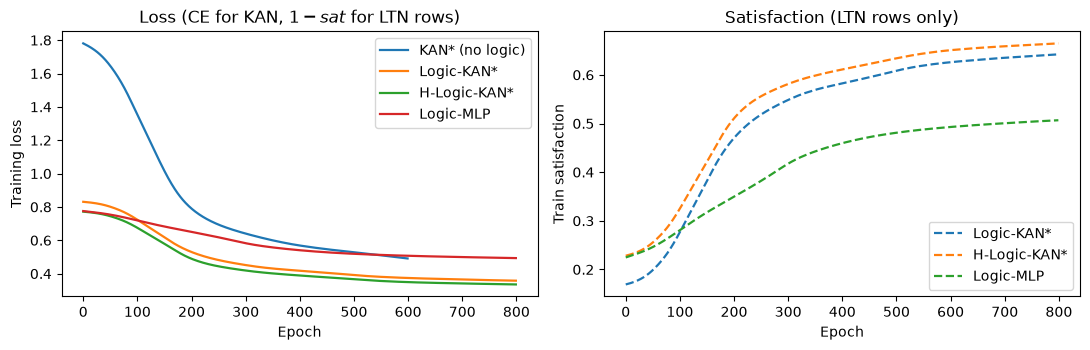

In [12]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(11, 3.6))
# only plot variants that have actually been run
for key in [k for k in VARIANTS if k in records]:
    r = records[key]
    axs[0].plot(r['hist_loss'], label=r['name'], linewidth=1.6)
    if not np.all(np.isnan(r['hist_sat'])):
        axs[1].plot(r['hist_sat'], label=r['name'], linewidth=1.6, linestyle='--')
axs[0].set_xlabel('Epoch'); axs[0].set_ylabel('Training loss')
axs[0].set_title('Loss (CE for KAN, $1-sat$ for LTN rows)')
axs[0].legend()
axs[1].set_xlabel('Epoch'); axs[1].set_ylabel('Train satisfaction')
axs[1].set_title('Satisfaction (LTN rows only)')
axs[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'c2_convergence.png'), dpi=150,
            bbox_inches='tight')
plt.show()

### Save checkpoints + results

Checkpoints are state_dict-based: pykan's `Symbolic_KANLayer` holds lambdas that
cannot be pickled, so `torch.save(model, ...)` would fail. Rebuild and
`load_state_dict` to reload.

In [13]:
out = {'seed': SEED, 'train_path': TRAIN_PATH, 'test_path': TEST_PATH,
       'kan_width': KAN_WIDTH, 'lr': LR, 'fast_dev': FAST_DEV, 'variants': {}}

# Save only the variants present in `records`, so a partial run (e.g. Row 4
# alone) writes its own checkpoint without touching the others.
RAN = [k for k in VARIANTS if k in records]
for key in RAN:
    r, res = records[key], results[key]
    ckpt_path = os.path.join(SAVE_DIR, f'{key}_2_6.pt')
    torch.save({
        'model_state': models[key].state_dict(),
        'variant': key, 'backward': r['backward'],
        'config': {'IN_FEATURES': IN_FEATURES, 'N_CLASSES': N_CLASSES,
                   'KAN_WIDTH': KAN_WIDTH, 'SEED': SEED,
                   'X_columns': X_columns, 'label_L2_names': label_L2_names,
                   'BENIGN_L2': BENIGN_L2},
        'scaler_mean': scaler.mean_, 'scaler_scale': scaler.scale_,
        'history': {'loss': r['hist_loss'], 'sat': r['hist_sat']},
        'stop_epoch': r['stop_epoch'],
        'metrics': {k: v for k, v in res.items() if not k.startswith('_')},
    }, ckpt_path)

    out['variants'][key] = {
        'name': r['name'], 'backward': r['backward'],
        'stop_epoch': r['stop_epoch'], 'params': r['params'],
        'seconds': r['seconds'],
        'metrics': {k: v for k, v in res.items()
                    if not k.startswith('_') and k != 'per_class_recall'},
        'per_class_recall': {str(c): float(v)
                             for c, v in res['per_class_recall'].items()},
    }
    print('saved ->', ckpt_path)

res_path = os.path.join(SAVE_DIR, 'c2_single_run.json')
with open(res_path, 'w') as f:
    json.dump(out, f, indent=2, default=float)
print('saved ->', res_path)

saved -> ./saved/kan_star_ce_2_6.pt
saved -> ./saved/logic_kan_star_2_6.pt
saved -> ./saved/h_logic_kan_star_2_6.pt
saved -> ./saved/logic_mlp_hier_2_6.pt
saved -> ./saved/c2_single_run.json


## Next steps

1. **Copy each `plateau@` into `CONVERGE`** in `run_multiseed_c2.py`. The three
   KAN rows are already set (600 / 800 / 800); `logic_mlp_hier` is deliberately
   left as `None` there, so the harness refuses to run it until you supply a
   measured budget.
2. **Check the ordering makes sense** before scaling up — does adding the logic
   tensor, and then the hierarchy rule, move the metrics the way the paper claims?
   If not, that is worth understanding now rather than after a 5-seed sweep.
3. **Then** run the multi-seed version to get mean ± std and the paired tests for
   the actual table.

### Reload a checkpoint

```python
import torch
from utils import MultiKANModel
from kan import KAN

ckpt = torch.load('./saved/h_logic_kan_2_6.pt', map_location=device,
                  weights_only=False)
cfg = ckpt['config']
kan = KAN(width=cfg['KAN_WIDTH'], grid=5, k=3, seed=cfg['SEED'], device=device,
          auto_save=False, save_act=False)
model = MultiKANModel(kan).to(device)
model.load_state_dict(ckpt['model_state'])
model.eval()

# re-apply the saved scaler to raw features before inference:
#   X = (X_raw - ckpt['scaler_mean']) / ckpt['scaler_scale']
```